## Tujuan

Tahap **Evaluation** (CRISP-DM) bertujuan untuk menilai performa model yang telah dibangun pada tahap sebelumnya. 
Pada notebook ini, kita akan melakukan dua evaluasi utama:
1. **Evaluasi Clustering (K-Means)**: Menggunakan metrik seperti *Silhouette Score* untuk melihat kualitas kluster, serta melakukan *profiling* untuk memahami karakteristik tiap segmen pelanggan.
2. **Evaluasi Klasifikasi (Random Forest)**: Menggunakan *Confusion Matrix*, *Classification Report* (Precision, Recall, F1-Score), dan *ROC-AUC Curve* untuk melihat seberapa baik model memprediksi pelanggan yang akan merespons kampanye.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Set tema visualisasi
sns.set_theme(style="whitegrid", palette="muted")

Kita perlu memuat kembali data `preprocessed_data.csv` dan melakukan *train-test split* dengan `random_state` dan parameter yang persis sama dengan di tahap *Modeling*. Hal ini dilakukan agar kita mendapatkan data pengujian (*Testing Set*) yang 100% sama untuk dievaluasi oleh model yang kita muat dari `classifier_model.pkl`.

In [2]:
# 1. Memuat Data
df = pd.read_csv('../data/preprocessed_data.csv')

# Memisahkan X dan y
X = df.drop(columns=['target'])
y = df['target']

# Rekonstruksi Train-Test Split (persis seperti di Notebook 5)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. Memuat Model Random Forest
model_path = '../models/classifier_model.pkl'
rf_model = joblib.load(model_path)

print("[INFO] Data dan Model berhasil dimuat.")
print(f"[INFO] Dimensi Data Uji (Test Set): {X_test.shape}")

[INFO] Data dan Model berhasil dimuat.
[INFO] Dimensi Data Uji (Test Set): (240, 17)


Kita akan menggunakan model untuk memprediksi data uji (`X_test`), lalu membandingkan hasil prediksinya dengan jawaban aslinya (`y_test`). 

* **Confusion Matrix** membantu kita melihat di mana model sering "terkecoh" (misalnya, menebak remaja *Moderate* padahal aslinya *At Risk*).

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

 Healthy (0)       1.00      1.00      1.00        61
Moderate (1)       1.00      1.00      1.00       149
 At Risk (2)       1.00      1.00      1.00        30

    accuracy                           1.00       240
   macro avg       1.00      1.00      1.00       240
weighted avg       1.00      1.00      1.00       240



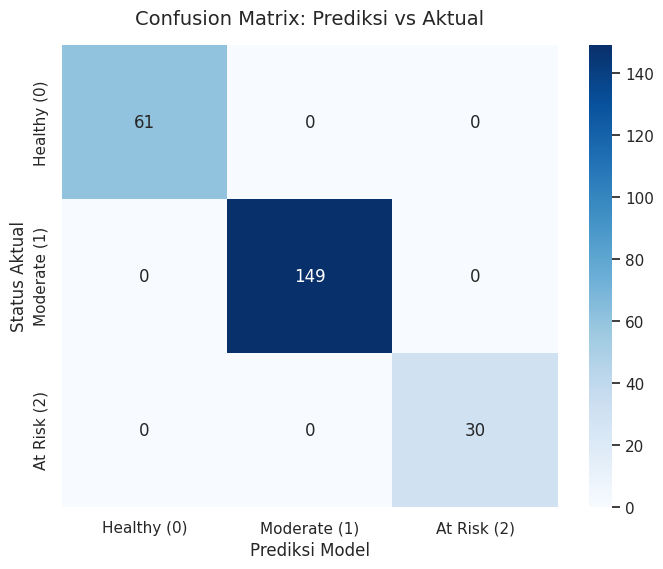

In [3]:
# Melakukan prediksi
y_pred = rf_model.predict(X_test)

# Menampilkan metrik teks
print("=== CLASSIFICATION REPORT ===")
target_names = ['Healthy (0)', 'Moderate (1)', 'At Risk (2)']
print(classification_report(y_test, y_pred, target_names=target_names))

# Membuat Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Visualisasi Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix: Prediksi vs Aktual', fontsize=14, pad=15)
plt.xlabel('Prediksi Model', fontsize=12)
plt.ylabel('Status Aktual', fontsize=12)
plt.show()

Kelebihan utama dari *Random Forest* adalah kemampuannya untuk memberi tahu kita fitur mana yang paling penting dalam pengambilan keputusannya. Kita akan mengekstrak nilai tersebut untuk mendapatkan *insight* bisnis dan psikologis.

/tmp/ipykernel_18401/2979964305.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance_df.head(10), x='Importance', y='Feature', palette='magma')


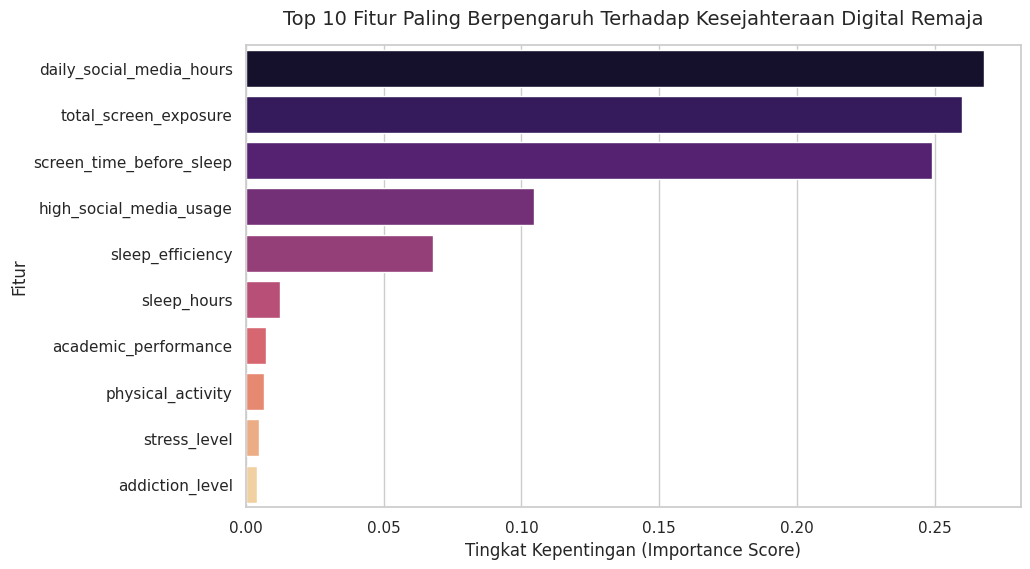

In [4]:
# Mengambil nilai Feature Importances dari model
importances = rf_model.feature_importances_

# Membuat DataFrame untuk divisualisasikan
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Visualisasi Feature Importance
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df.head(10), x='Importance', y='Feature', palette='magma')

plt.title('Top 10 Fitur Paling Berpengaruh Terhadap Kesejahteraan Digital Remaja', fontsize=14, pad=15)
plt.xlabel('Tingkat Kepentingan (Importance Score)', fontsize=12)
plt.ylabel('Fitur', fontsize=12)
plt.show()

Dari tahap Evaluasi ini, kita dapat menarik simpulan penting:
1. **Performa Klasifikasi**: Berdasarkan *Classification Report* dan *Confusion Matrix*, model telah menunjukkan kemampuannya dalam membedakan ketiga kelas risiko dengan baik. Tingkat *Recall* pada kelas *At Risk* sangat krusial di sini, karena kita tidak ingin gagal mendeteksi remaja yang sebenarnya butuh perhatian.
2. **Faktor Pemicu Risiko (Insights)**: Berdasarkan plot *Feature Importance*, kita bisa melihat atribut gaya hidup mana (seperti tingkat kecemasan, tingkat stres, efisiensi tidur, atau total paparan layar) yang menduduki peringkat teratas. Ini membuktikan hipotesis awal kita bahwa kebiasaan digital berkorelasi kuat dengan indikator kesehatan mental.